In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import time

Data Shape: (10000, 100)


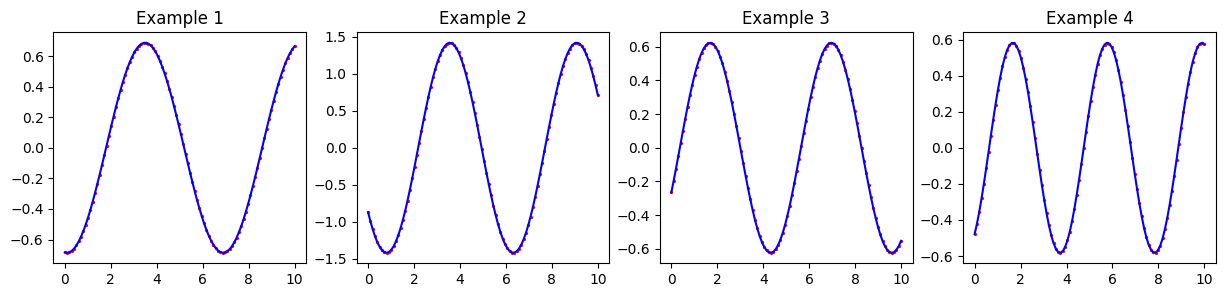

In [20]:
# Generate Data
n_samples = 10000
n_points = 100
t = np.linspace(0, 10, n_points)

clean_data = np.zeros((n_samples, n_points))
for i in range(n_samples):
    A = np.random.uniform(0.5, 1.5)
    w = np.random.uniform(0.5, 2.0)
    phi = np.random.uniform(0, 2 * np.pi)
    clean_data[i] = A * np.sin(w * t + phi)

print('Data Shape:', clean_data.shape)

# Plotting 4 examples
fig, axes = plt.subplots(1, 4, figsize=(15, 3))
for i in range(4):
    axes[i].plot(t, clean_data[i], color='blue')
    axes[i].scatter(t, clean_data[i], color='r', lw=0.1, s=5)
    axes[i].set_title(f"Example {i+1}")
plt.show()

In [21]:
# Add Noise
noise_factor = 0.2
noisy_data = clean_data + np.random.normal(loc=0.0, scale=noise_factor, size=clean_data.shape)
#noisy_data = clean_data + np.random.laplace(loc=0.0, scale=noise_factor, size=clean_data.shape)

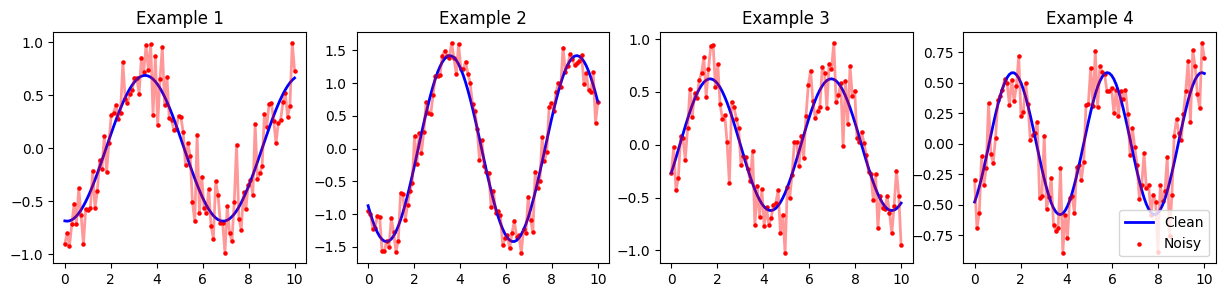

In [28]:
# Plotting 4 examples
fig, axes = plt.subplots(1, 4, figsize=(15, 3))
for i in range(4):
    axes[i].plot(t, clean_data[i], label='Clean', color='blue', lw=2)
    axes[i].scatter(t, noisy_data[i], color='red', label='Noisy', s=5)
    axes[i].plot(t, noisy_data[i], color='red', alpha = 0.4, lw=2)
    axes[i].set_title(f"Example {i+1}")
plt.legend()
plt.show()

In [34]:
# Train/Test Split
x_train_noisy, x_valid_noisy, x_train_clean, x_valid_clean = train_test_split(
    noisy_data, clean_data, test_size=0.1, random_state=42)

print('Training set shape:', x_train_noisy.shape)
print('Validation set shape:', x_valid_noisy.shape)

Training set shape: (9000, 100)
Validation set shape: (1000, 100)


In [51]:
# Build Architecture
input_layer = Input(shape=(n_points,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
bottleneck = Dense(3, activation='relu')(encoded)

decoded = Dense(32, activation='relu')(bottleneck)
decoded = Dense(64, activation='relu')(decoded)
output_layer = Dense(n_points, activation='linear')(decoded)

autoencoder = Model(input_layer, output_layer)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 3)              │            99 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,383 (67.90 KB)

 Trainable params: 17,383 (67.90 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
# Train the model and record time/history
start_time = time.time()
history = autoencoder.fit(x_train_noisy, x_train_clean,
                          epochs=50,
                          batch_size=64,
                          shuffle=True,
                          validation_data=(x_valid_noisy, x_valid_clean),
                          verbose=1) # Set to 1 to see progress

end_time = time.time()
print(f"Training Time: {end_time - start_time:.2f} seconds")

# Reconstruct validation data
reconstructed = autoencoder.predict(x_valid_noisy)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4117 - val_loss: 0.3346
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3150 - val_loss: 0.2949
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2627 - val_loss: 0.2427
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2237 - val_loss: 0.2197
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2053 - val_loss: 0.2016
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1922 - val_loss: 0.1945
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1804 - val_loss: 0.1827
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1704 - val_loss: 0.1704
Epoch 9/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1624 - val_loss: 0.1648
Epoch 10/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1559 - val_loss: 0.1570
Epoch 11/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1502 - val_loss: 0.1486
Epoch 12/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

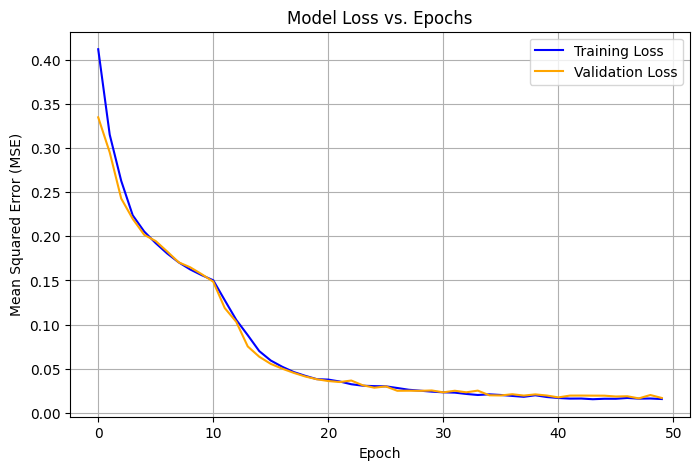

In [53]:
# Plot: Training and Validation Loss vs Epochs

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

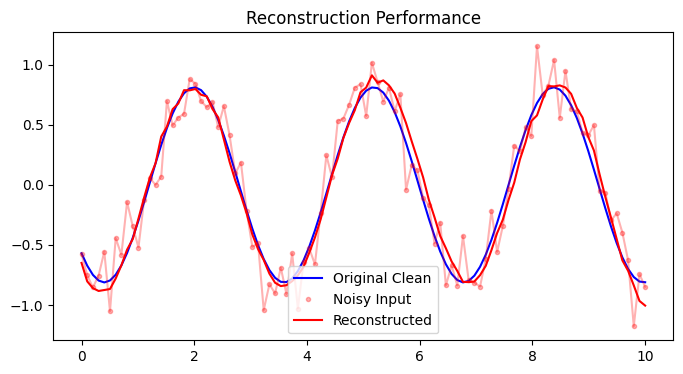

In [54]:
# Plot
plt.figure(figsize=(8, 4))
plt.plot(t, x_valid_clean[0], 'b-', label='Original Clean')
plt.plot(t, x_valid_noisy[0], 'r.', alpha=0.3, label='Noisy Input')
plt.plot(t, x_valid_noisy[0], 'r', alpha=0.3)
plt.plot(t, reconstructed[0], 'r', label='Reconstructed')
plt.legend()
plt.title("Reconstruction Performance")
plt.show()